# 🏦 Loan Prediction System

## 📌 About this Notebook
This notebook explores the **Loan Prediction Dataset**, which contains information about loan applicants and their loan application status. The dataset is commonly used for **classification tasks** in machine learning, where the goal is to predict whether a loan will be **approved (Y) or not approved (N)**.

It contains **614 records** with **13 columns**, representing applicant details, financial background, and property information. Below is a detailed explanation of each column:

### 🔹 Dataset Columns

1. **Loan_ID**  
   A unique identifier assigned to each loan application.  
   Example: `LP001002`

2. **Gender**  
   Gender of the applicant.  
   Values: `Male`, `Female`

3. **Married**  
   Marital status of the applicant.  
   Values: `Yes`, `No`

4. **Dependents**  
   Number of dependents (children or family members financially dependent).  
   Values: `0`, `1`, `2`, `3+`

5. **Education**  
   Educational qualification of the applicant.  
   Values: `Graduate`, `Not Graduate`

6. **Self_Employed**  
   Indicates if the applicant is self-employed.  
   Values: `Yes`, `No`

7. **ApplicantIncome**  
   The monthly income of the main applicant.  
   Type: Integer (e.g., `4583`)

8. **CoapplicantIncome**  
   The monthly income of the co-applicant (spouse/partner).  
   Type: Float (e.g., `1508.0`)

9. **LoanAmount**  
   The loan amount requested (in thousands).  
   Example: `128` → represents 128,000  

10. **Loan_Amount_Term**  
    The term/duration of the loan (in months).  
    Example: `360` → represents 30 years  

11. **Credit_History**  
    Applicant’s credit history, indicating whether they have a good repayment record.  
    Values:  
    - `1.0` → Good credit history  
    - `0.0` → Poor or no credit history  

12. **Property_Area**  
    The type of area where the property is located.  
    Values: `Urban`, `Semiurban`, `Rural`

13. **Loan_Status** (Target Variable)  
    The final decision on the loan application.  
    Values:  
    - `Y` → Loan approved  
    - `N` → Loan not approved  

---

## 🎯 Objective
The main objective of this project is to:
1. **Analyze** the applicant and loan data.  
2. **Preprocess** the dataset by handling missing values and categorical variables.  
3. **Build a predictive model** to classify whether a loan will be approved.  

This type of system is useful for:
- **Banks & Financial Institutions** → to automate and speed up loan approval decisions.  
- **Applicants** → to understand the key factors that influence loan approval.  

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=df=pd.read_csv('Loan_Predication.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


# Preprocessing

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3
Education,0
Loan_ID,0
CoapplicantIncome,0


In [ ]:
Credit_nan = df[df.isna().any(axis=1)]

In [ ]:
Credit_nan[Credit_nan['Dependents'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
102,LP001350,Male,Yes,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
120,LP001426,Male,Yes,NaN,Graduate,No,5667,2667.0,180.0,360.0,1.0,Rural,Y
226,LP001754,Male,Yes,NaN,Not Graduate,Yes,4735,0.0,138.0,360.0,1.0,Urban,N
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
293,LP001945,Female,No,NaN,Graduate,No,5417,0.0,143.0,480.0,0.0,Urban,N
301,LP001972,Male,Yes,NaN,Not Graduate,No,2875,1750.0,105.0,360.0,1.0,Semiurban,Y
332,LP002100,Male,No,NaN,Graduate,No,2833,0.0,71.0,360.0,1.0,Urban,Y
335,LP002106,Male,Yes,NaN,Graduate,Yes,5503,4490.0,70.0,NaN,1.0,Semiurban,Y
346,LP002130,Male,Yes,NaN,Not Graduate,No,3523,3230.0,152.0,360.0,0.0,Rural,N


If the dependents column has a nan, it will be replaced with zero, and if it has a 3+ value, it will be replaced with 4 or 5 randomly

In [ ]:
df['Dependents'] = df['Dependents'].fillna('0')

In [ ]:
df.loc[df['Dependents'] == '3+', 'Dependents'] = np.random.choice([4, 5], size=df[df['Dependents'] == '3+'].shape[0])

Married column has 3 nan values, so I decided:
1. If gender is female and the coapplicantincome is not equal to zero (she has a husband), the married value in this case will be YES. Otherwise she is single

2. If gender is male, the mareid status will be YES for any value of coapplicantincome




In [ ]:
df.loc[(df['Married'].isna()) & (df['Gender'] == 'Female') & (df['CoapplicantIncome'] == 0.0), 'Married'] = 'Yes'
df.loc[(df['Married'].isna()) & (df['Gender'] == 'Male'), 'Married'] = 'Yes'

Replace the nan values at column LoanAmount with mean

In [ ]:
Credit_nan = df[df.isna().any(axis=1)]
Credit_nan[Credit_nan['LoanAmount'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,LP001213,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,LP001266,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
102,LP001350,Male,Yes,0,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
113,LP001392,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban,Y
127,LP001449,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural,Y
202,LP001682,Male,Yes,5,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N


In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

Replace LoanAmountTerm with Medien

In [ ]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [ ]:
Credit_nan = df[df.isna().any(axis=1)]
Credit_nan[Credit_nan['Credit_History'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.000000,240.0,NaN,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.000000,360.0,NaN,Semiurban,N
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.000000,360.0,NaN,Urban,N
42,LP001123,Male,Yes,0,Graduate,No,2400,0.0,75.000000,360.0,NaN,Urban,Y
79,LP001264,Male,Yes,5,Not Graduate,Yes,3333,2166.0,130.000000,360.0,NaN,Semiurban,Y
83,LP001273,Male,Yes,0,Graduate,No,6000,2250.0,265.000000,360.0,NaN,Semiurban,N
86,LP001280,Male,Yes,2,Not Graduate,No,3333,2000.0,99.000000,360.0,NaN,Semiurban,Y
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,146.412162,360.0,NaN,Urban,N
117,LP001405,Male,Yes,1,Graduate,No,2214,1398.0,85.000000,360.0,NaN,Urban,Y
125,LP001443,Female,No,0,Graduate,No,3692,0.0,93.000000,360.0,NaN,Rural,Y


In [ ]:
display(df[(df['Loan_Status'] == 'Y') & (df['Credit_History'] == 0.0)])

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
122,LP001431,Female,No,0,Graduate,No,2137,8980.0,137.0,360.0,0.0,Semiurban,Y
155,LP001536,Male,Yes,4,Graduate,No,39999,0.0,600.0,180.0,0.0,Semiurban,Y
201,LP001677,Male,No,2,Graduate,No,4923,0.0,166.0,360.0,0.0,Semiurban,Y
267,LP001882,Male,Yes,5,Graduate,No,4333,1811.0,160.0,360.0,0.0,Urban,Y
326,LP002068,Male,No,0,Graduate,No,4917,0.0,130.0,360.0,0.0,Rural,Y
453,LP002449,Male,Yes,0,Graduate,No,2483,2466.0,90.0,180.0,0.0,Rural,Y
527,LP002706,Male,Yes,1,Not Graduate,No,5285,1430.0,161.0,360.0,0.0,Semiurban,Y


In [ ]:
# Create a copy of the DataFrame to avoid modifying the original while iterating
df_copy = df.copy()

# Iterate through rows with missing Credit_History
for index, row in df_copy[df_copy['Credit_History'].isna()].iterrows():
    # Conditions for setting Credit_History = 1 (Loan Status = N characteristics)
    conditions_for_credit_1 = (
        (row['Loan_Status'] == 'N') and
        (row['ApplicantIncome'] < df_copy['ApplicantIncome'].median()) and # Low income compared to loan amount (using median as a proxy for 'low')
        (row['CoapplicantIncome'] > 0) and # Heavy reliance on coapplicant’s income
        (row['LoanAmount'] > row['ApplicantIncome'] + row['CoapplicantIncome']) and # Loan amount too high relative to total income (simplified check)
        (row['Loan_Amount_Term'] > df_copy['Loan_Amount_Term'].median()) and # Very long loan duration
        (row['Education'] == 'Not Graduate') and
        (row['Self_Employed'] == 'Yes') and
        (row['Property_Area'] == 'Rural')
    )

    # Conditions for setting Credit_History = 0 (Loan Status = Y characteristics)
    conditions_for_credit_0 = (
        (row['Loan_Status'] == 'Y') and
        (row['ApplicantIncome'] > df_copy['ApplicantIncome'].median()) and # Very high applicant income
        (row['CoapplicantIncome'] == 0.0) and # Strong coapplicant income (but the user mentioned it's not zero for 'N', so maybe implicit for 'Y'?)
        (row['LoanAmount'] < row['ApplicantIncome']) and # Loan amount reasonable compared to total income (simplified check)
        (row['Loan_Amount_Term'] < df_copy['Loan_Amount_Term'].median()) and # Shorter loan term
        (row['Education'] == 'Graduate') and
        (row['Property_Area'] in ['Semiurban', 'Urban'])
    )

    # Apply the logic to impute Credit_History
    if conditions_for_credit_1:
        df.loc[index, 'Credit_History'] = 1.0
    elif conditions_for_credit_0:
        df.loc[index, 'Credit_History'] = 0.0
    else:
        # If neither set of conditions is met, use a default strategy (e.g., mode)
        # For simplicity here, let's use the mode of the non-missing Credit_History values
        df.loc[index, 'Credit_History'] = df['Credit_History'].mode()[0]

# Check the number of remaining missing values in Credit_History
print("Remaining missing values in Credit_History:", df['Credit_History'].isna().sum())

Remaining missing values in Credit_History: 0


In [103]:
# Impute missing 'Self_Employed' values with the mode
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Check the number of remaining missing values in Self_Employed
print("Remaining missing values in Self_Employed:", df['Self_Employed'].isna().sum())

Remaining missing values in Self_Employed: 0


In [146]:
display(df[df['Gender'].isna()][['Gender', 'ApplicantIncome', 'CoapplicantIncome','Married']] )

,Gender,ApplicantIncome,CoapplicantIncome,Married


In [112]:
# Impute missing 'Gender' values based on specific rules
df.loc[23, 'Gender'] = 'Male' # Index 23 → Married Yes, ApplicantIncome > CoapplicantIncome → Male
df.loc[126, 'Gender'] = 'Male' # Index 126 → Very high income (23803), Married Yes, CoapplicantIncome = 0 → Male
df.loc[171, 'Gender'] = 'Male' # Index 171 → Very high income (51763), Married Yes, CoapplicantIncome = 0 → Male
df.loc[188, 'Gender'] = 'Female' # Index 188 → ApplicantIncome low (674), CoapplicantIncome high (5296), Married Yes → Female (likely husband is co-applicant)
df.loc[314, 'Gender'] = 'Male' # Index 314 → ApplicantIncome > CoapplicantIncome, Married Yes → Male
df.loc[334, 'Gender'] = 'Male' # Index 334 → ApplicantIncome > CoapplicantIncome, Married Yes → Male
df.loc[460, 'Gender'] = 'Female' # Index 460 → ApplicantIncome < CoapplicantIncome (2083 vs 4083), Married Yes → Female
df.loc[467, 'Gender'] = 'Male' # Index 467 → High income (16692), CoapplicantIncome = 0, Married Yes → Male
df.loc[477, 'Gender'] = 'Male' # Index 477 → ApplicantIncome > CoapplicantIncome, Married Yes → Male
df.loc[507, 'Gender'] = 'Male' # Index 507 → ApplicantIncome only (3583, no coapplicant), Married No → Male
df.loc[576, 'Gender'] = 'Male' # Index 576 → ApplicantIncome > CoapplicantIncome, Married Yes → Male
df.loc[588, 'Gender'] = 'Male' # Index 588 → ApplicantIncome only (4750), Married No → Male
df.loc[592, 'Gender'] = 'Male' # Index 592 → ApplicantIncome only (9357), Married No → Male

# Check the number of remaining missing values in Gender
print("Remaining missing values in Gender:", df['Gender'].isna().sum())

Remaining missing values in Gender: 0


# Visualization

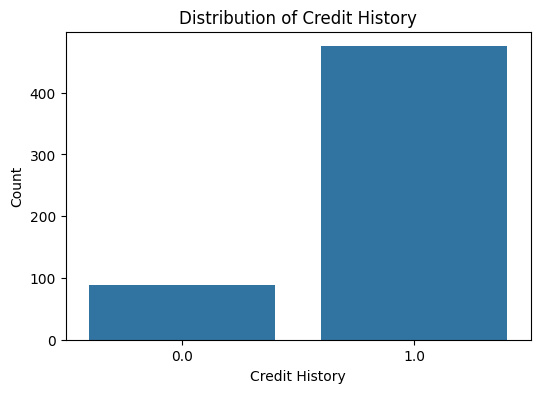

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Credit_History', data=df)
plt.title('Distribution of Credit History')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.show()

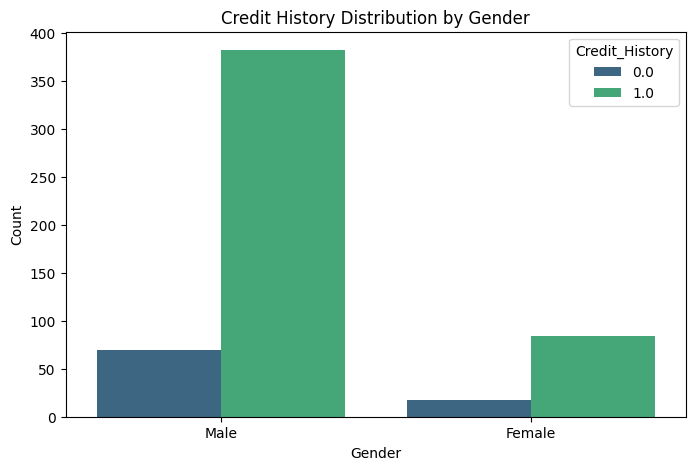

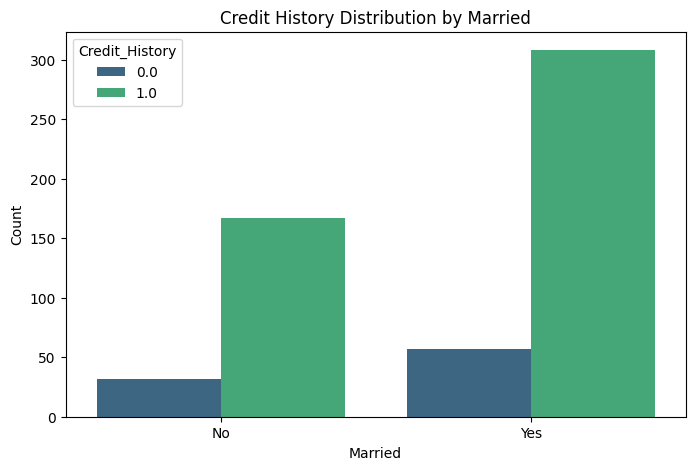

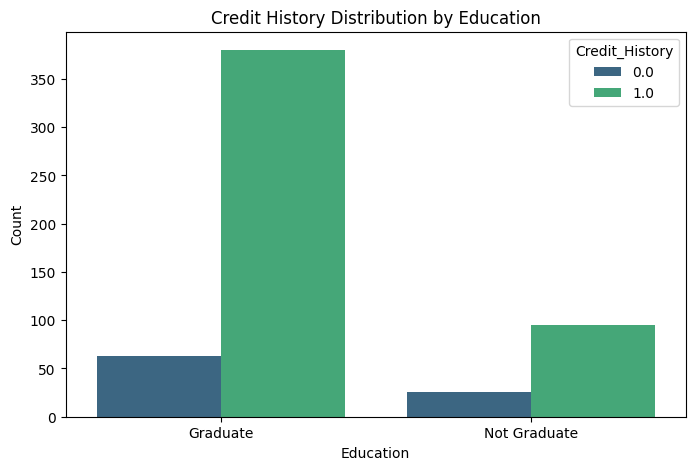

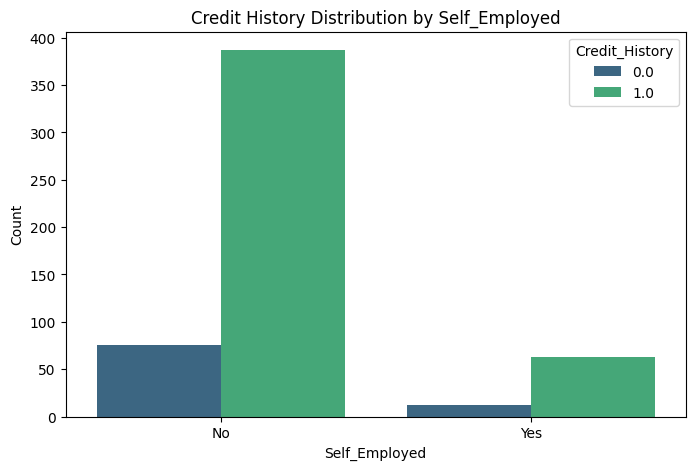

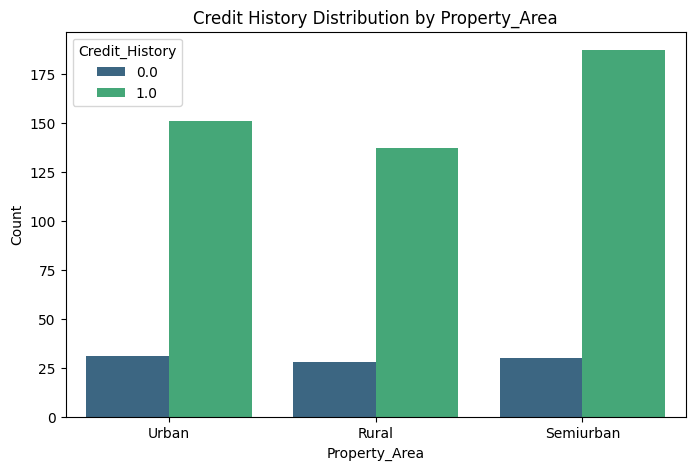

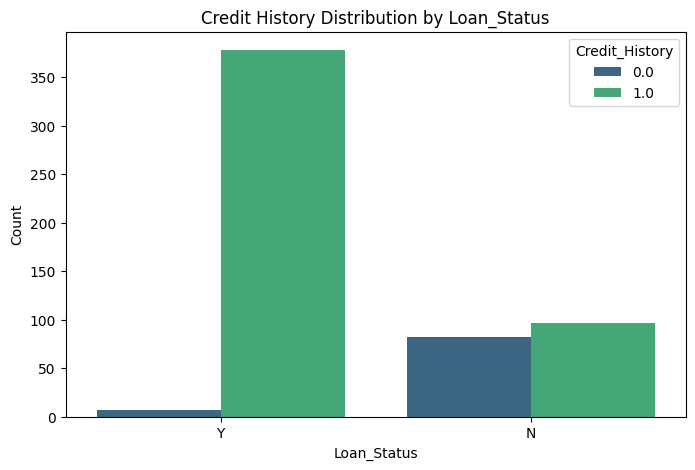

In [ ]:
categorical_cols_to_explore = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols_to_explore:
    if col != 'Credit_History':
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, hue='Credit_History', data=df, palette='viridis')
        plt.title(f'Credit History Distribution by {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

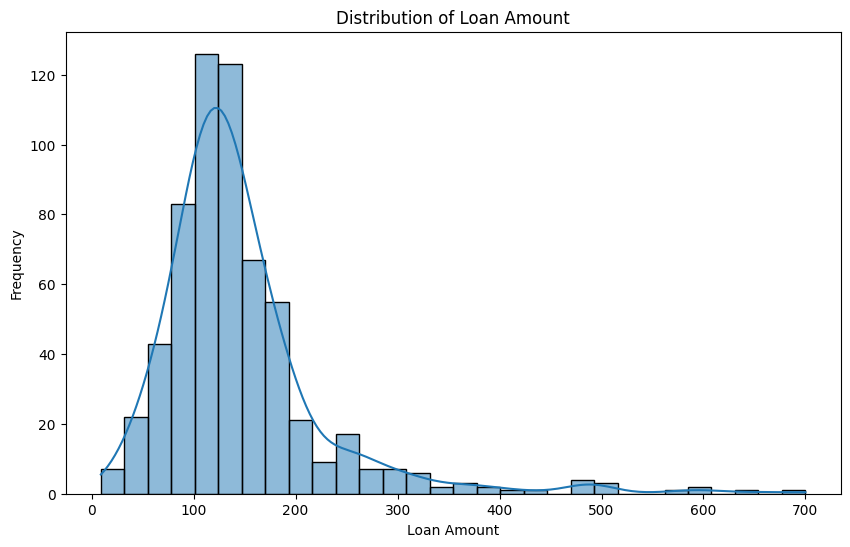

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['LoanAmount'].dropna(), kde=True, bins=30)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

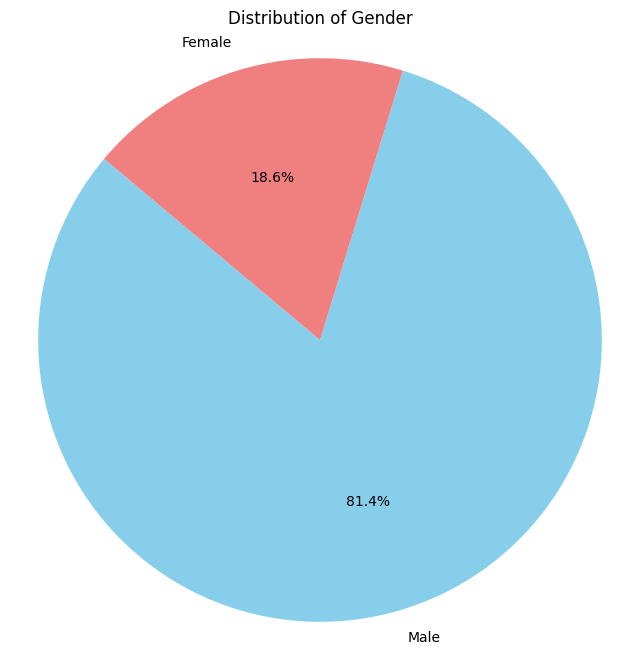

In [ ]:
# Count the occurrences of each gender
gender_counts = df['Gender'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Gender')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

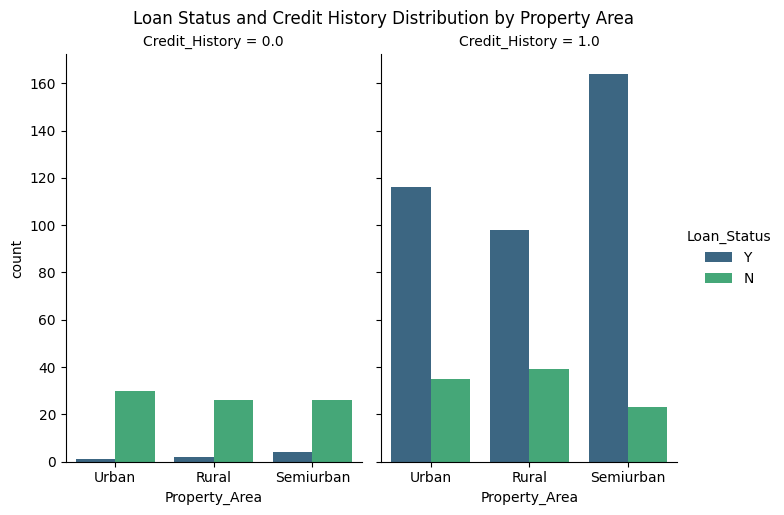

In [ ]:
sns.catplot(x='Property_Area', hue='Loan_Status', col='Credit_History', data=df, kind='count', palette='viridis', height=5, aspect=.7)
plt.suptitle('Loan Status and Credit History Distribution by Property Area', y=1.02)
plt.show()

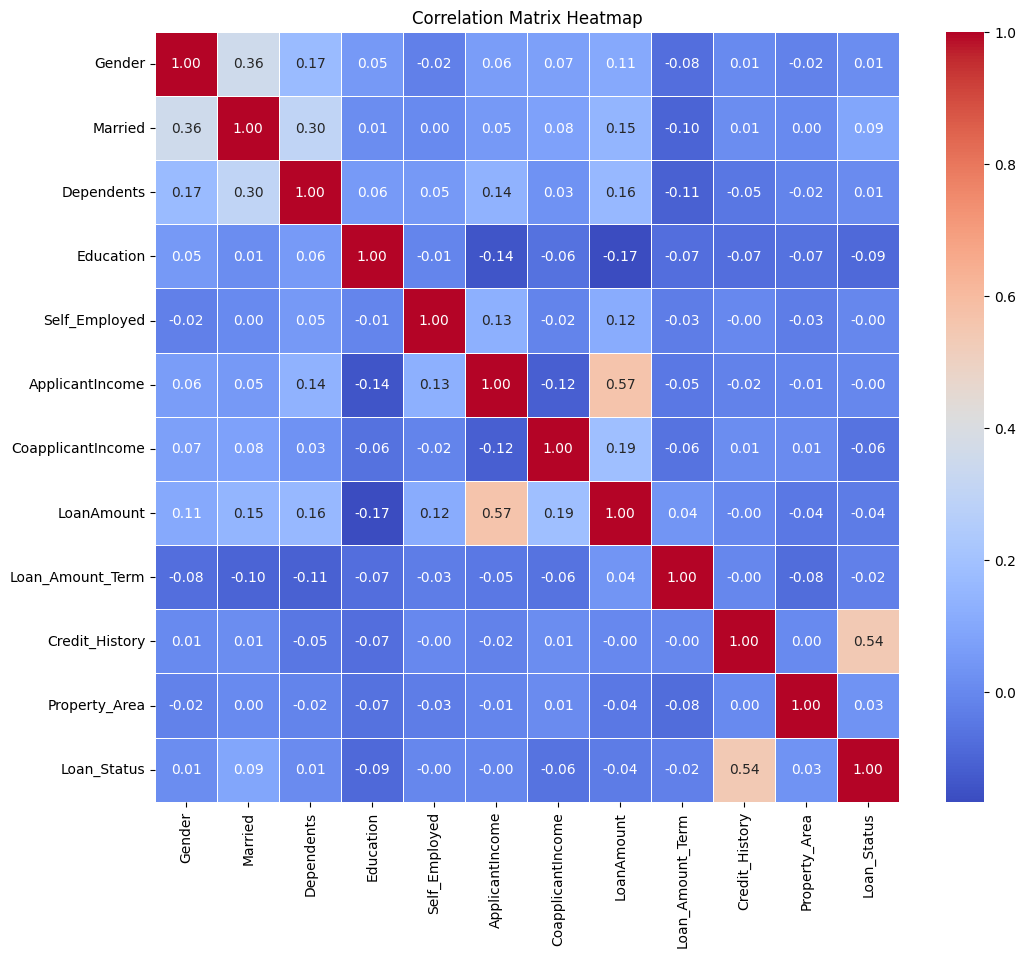

In [125]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

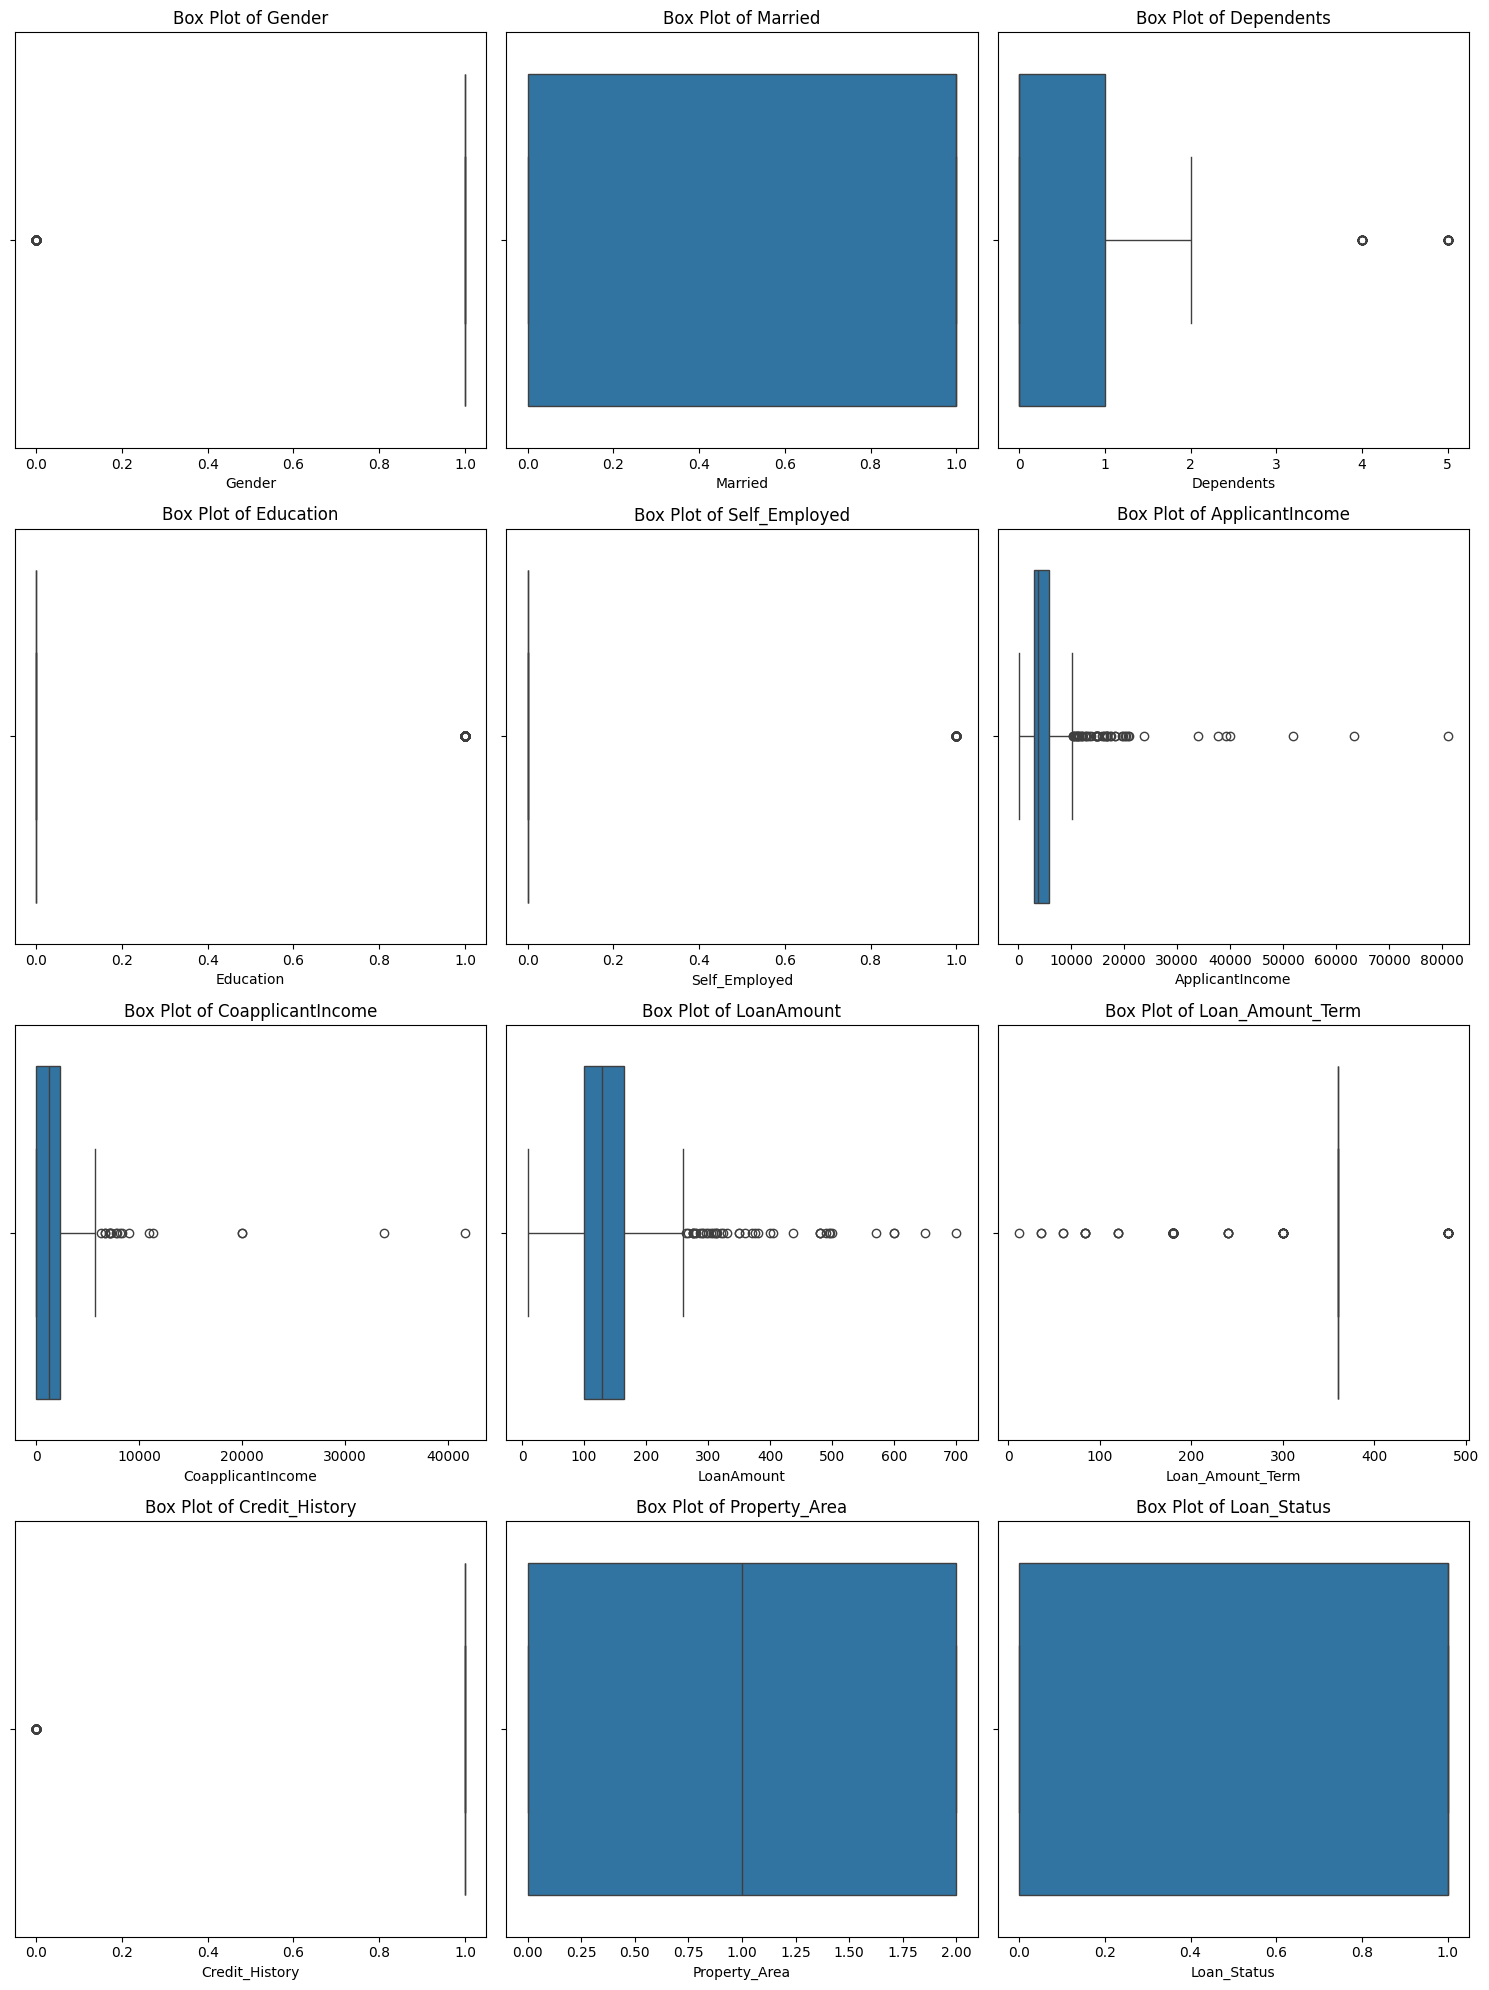

In [124]:
# Select only the numeric columns for outlier detection
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Create box plots for each numeric column to visualize outliers
plt.figure(figsize=(15, 20)) # Increased figure size for more rows
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1) # Changed to a 4x3 grid
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# Encodding

In [117]:
from sklearn.preprocessing import LabelEncoder

# Select only the categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'Loan_ID' as it's just an identifier
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')

# Convert 'Dependents' column to numeric before encoding
df['Dependents'] = df['Dependents'].astype(int)

# Apply Label Encoding to the remaining categorical columns
label_encoders = {}
# Re-select categorical columns after converting 'Dependents'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


# Imbalanced

Distribution of Loan_Status:


,count
Loan_Status,
1,422
0,192


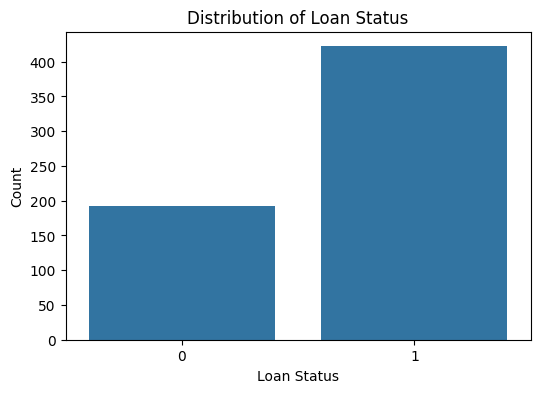

In [128]:
# Check for class imbalance in the target variable
print("Distribution of Loan_Status:")
display(df['Loan_Status'].value_counts())

# You can also visualize this with a countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [119]:
df.drop('Loan_ID', axis=1, inplace=True)

In [126]:
# Get the correlation of each column with 'Loan_Status'
loan_status_correlation = correlation_matrix['Loan_Status'].sort_values(ascending=False)

# Display the correlations
print("Correlation with Loan_Status:")
display(loan_status_correlation)

Correlation with Loan_Status:


,Loan_Status
Loan_Status,1.000000
Credit_History,0.540556
Married,0.091478
Property_Area,0.032112
Gender,0.012213
Dependents,0.006829
Self_Employed,-0.003700
ApplicantIncome,-0.004710
Loan_Amount_Term,-0.022549
LoanAmount,-0.036416


In [139]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Separate features (X) and target variable (y)
# Include the previously selected columns and the newly added ones
feature_cols = ['Credit_History', 'Married', 'Property_Area', 'Gender',
                'Dependents', 'Self_Employed', 'ApplicantIncome', 'Loan_Amount_Term',
                'LoanAmount', 'CoapplicantIncome', 'Education']

X = df[feature_cols]
y = df['Loan_Status']

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original dataset shape:", Counter(y))
print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({1: 422, 0: 192})
Resampled dataset shape: Counter({1: 422, 0: 422})


# Spliting data

In [140]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (675, 11) (675,)
Testing set shape (X_test, y_test): (169, 11) (169,)


# Training models (KNN,SVM)

In [141]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn = KNeighborsClassifier()

# Define the parameter grid to search
param_grid = {'n_neighbors': range(1, 21)} # Search for k from 1 to 20

# Initialize GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy') # Using 5-fold cross-validation and accuracy as scoring

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for KNN:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# You can also get the best model
best_knn_model = grid_search.best_estimator_

Best parameters for KNN: {'n_neighbors': 1}
Best cross-validation accuracy: 0.68


In [143]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=1) # You can adjust the number of neighbors

# Train the model using the training data
knn_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = knn_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("KNN Model Accuracy:", accuracy)
print("\nKNN Model Classification Report:\n", report)

KNN Model Accuracy: 0.650887573964497

KNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68        85
           1       0.68      0.57      0.62        84

    accuracy                           0.65       169
   macro avg       0.65      0.65      0.65       169
weighted avg       0.65      0.65      0.65       169



In [144]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVM model
svm = SVC(random_state=42)

# Define the parameter grid to search
param_grid_svm = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'] # Kernel types
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy') # Using 5-fold cross-validation and accuracy as scoring

# Fit the grid search to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy:", grid_search_svm.best_score_)

# Get the best SVM model
best_svm_model = grid_search_svm.best_estimator_

# Make predictions on the testing data using the best model
y_pred_best_svm = best_svm_model.predict(X_test)

# Evaluate the best SVM model
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
report_best_svm = classification_report(y_test, y_pred_best_svm)

print("\nBest SVM Model Accuracy on Test Set:", accuracy_best_svm)
print("\nBest SVM Model Classification Report on Test Set:\n", report_best_svm)

Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Best cross-validation accuracy: 0.725925925925926

Best SVM Model Accuracy on Test Set: 0.7692307692307693

Best SVM Model Classification Report on Test Set:
               precision    recall  f1-score   support

           0       0.87      0.64      0.73        85
           1       0.71      0.90      0.80        84

    accuracy                           0.77       169
   macro avg       0.79      0.77      0.77       169
weighted avg       0.79      0.77      0.77       169

